In [21]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.naive_radar_tb import NaiveRadarTB
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.plotting.plotter_kalman import PlotterKalman
from odometry.plotting.movies import MovieGenerator


In [22]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK"
# file_name = "WILK_Multipath_Test_1"
# file_name = "WILK_Path_1_No_Dynamic"
file_name = "WILK_Multipath_Test_5"

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 2886 radar samples
found 2886 lidar samples
found 2886 camera samples
found 2886 imu (orientation only) samples
found 2886imu (full data) samples
found 2886 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [23]:
#initialize the localizers
radar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.5,#originally 0.1
    icp_best_points_percentile=80, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=20,
    self_detection_radius_m=1.5 #originally 1.5
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.1, #was 0.6, try 0.1
    icp_best_points_percentile=50, #was 50 - try 75
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=1.0 #was 0.25, try 1.0
)

loaded map with 20750 points
loaded map with 20750 points
gt icp estimated heading:-5.708390622483 deg, pose:[-0.06546079  0.21857452]


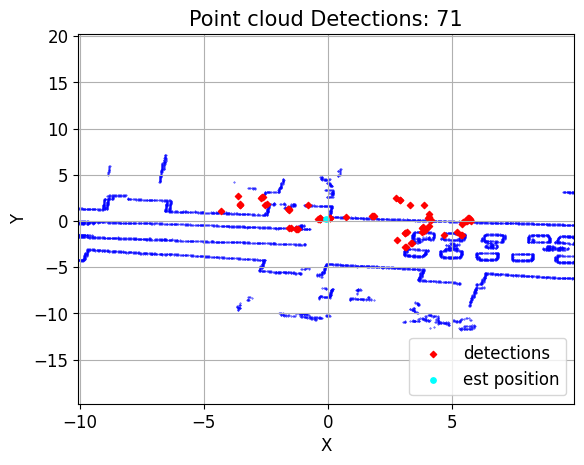

In [24]:
test_bench = NaiveRadarTB(
    localizer=radar_odometry,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
new_heading_rad,new_pose_m = test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    show=True
)

#initialize the filter
test_bench.init_filter(
    est_start_heading_rad=new_heading_rad,
    est_start_position_m=new_pose_m,
    start_time_s=test_bench.get_dataset_start_time(idx=0),
    gyro_bias=-0.0024
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


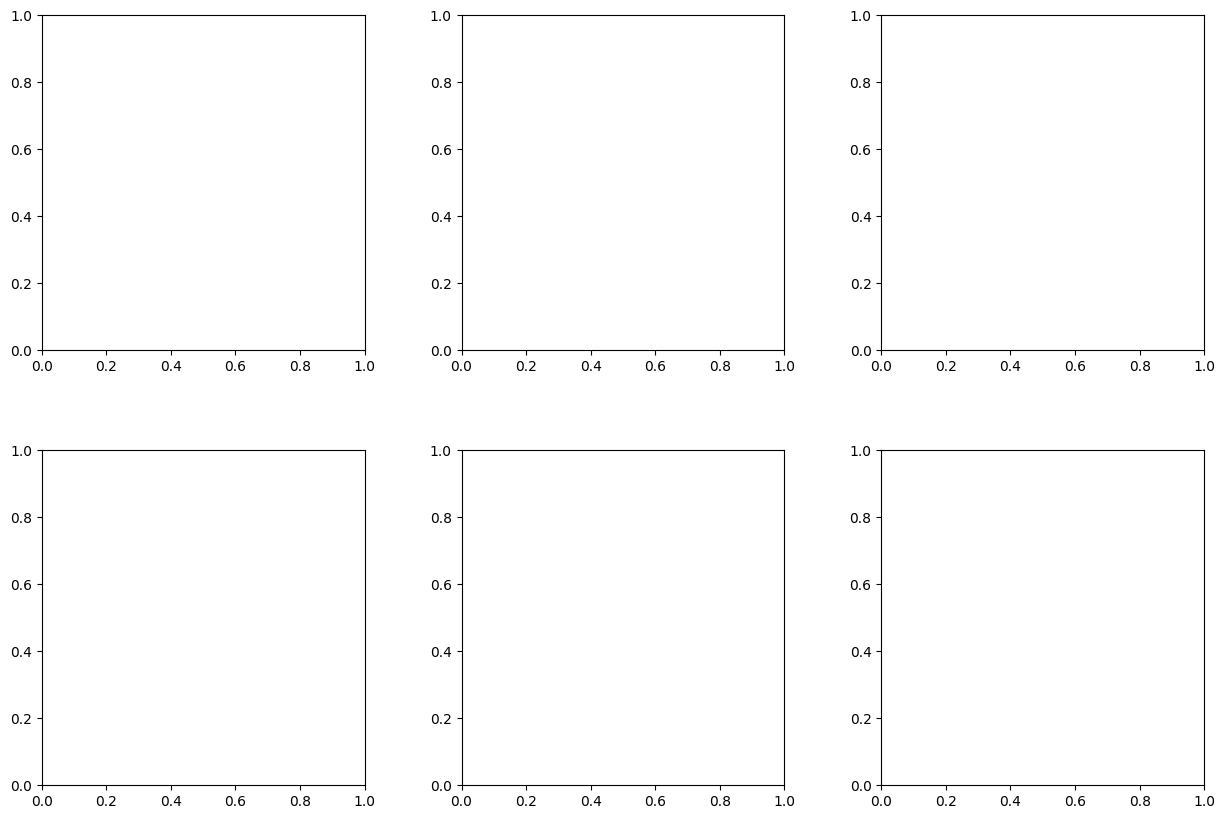

In [25]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=2,
    ncols=3,
    figsize=(15,10)
)

In [26]:
end_idx = 960 #dataset.num_frames #point cloud sample: frame 1340 on Wilk_Multipath_test_5
save_name = file_name + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None)

100%|██████████| 960/960 [00:27<00:00, 34.78it/s]


In [20]:
#evaluating processing times
update_periods = np.array(test_bench.history_update_periods)
processing_times = np.array(test_bench.history_update_actitve_compute_times)

percent_processing_times = 100 * np.divide(processing_times, update_periods)
np.save("processing_times/naive_radar.npy",percent_processing_times)

In [ ]:
np.save("Trajectories/gt.npy",test_bench.history_position_m_gt)
np.save("Trajectories/radar_icp_only.npy",test_bench.history_position_m)

In [ ]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

In [ ]:
test_bench.analyze(
    save_folder_path="Results",
    file_name=file_name,
    export_to_csv=False
)

In [ ]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

In [ ]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

fig.savefig("Images/position_history/{}.png".format(save_name))

In [ ]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

In [ ]:
#plot kalman state history
kalman_plotter = PlotterKalman()

kalman_plotter.plot_kalman_result_history(
    x_history=np.array(test_bench.history_filter_est),
    p_history=np.array(test_bench.history_filter_p),
    idx=-1
)



In [ ]:
gyro_bias_history = np.array(test_bench.history_filter_est)[:,4]
t = np.arange(0,gyro_bias_history.shape[0]) * 1/200
bias = np.rad2deg(0.0024)
error_due_to_bias = bias * 60
print("bias: {} deg/sec, over 1min: {} deg".format(bias,error_due_to_bias))
plt.plot(t,gyro_bias_history)


['map', 'detections', 'est position']


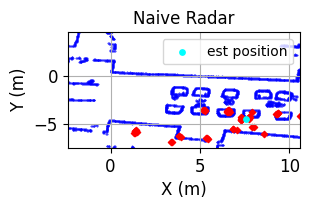

In [27]:
#visualizing the point cloud
fig, axs = plt.subplots(figsize=(3,1.5))

test_bench.plotter_localization.plot_detections_on_map(
    current_points=dataset.get_radar_detections(end_idx)[:,0:2],
    heading_rad=test_bench.filter.x[2],
    pose_m=test_bench.filter.x[0:2],
    ax=axs,
    show=False
) 
axs.set_title("Naive Radar",
                fontsize=test_bench.plotter_localization.font_size_legend)
axs.set_xlim(
    test_bench.filter.x[0] - 10,
    test_bench.filter.x[0] + 3)
axs.set_xlabel("X (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
axs.set_ylim(
    test_bench.filter.x[1] - 3,
    test_bench.filter.x[1] + 9)
axs.set_ylabel("Y (m)",fontsize=test_bench.plotter_localization.font_size_axis_labels)
handles,labels = axs.get_legend_handles_labels()
print(labels)
axs.legend(handles[2:3], labels[2:3], loc="upper right",fontsize=10)

plt.show()

### Debugging ICP

In [ ]:
#get the point cloud (from the previous step)
current_points = test_bench.dataset.get_radar_detections(idx=-1)[:,0:2]
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.filter.x[2],
    pose_m= test_bench.filter.x[0:2],
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [ ]:
#configure icp for only a single update
test_bench.localizer.icp_max_iterations = 1

#update the odometry
for i in tqdm(range(500)):
    new_heading_rad,new_pose_m = test_bench.localizer.update_odometry(
        points=current_points,
        estimated_heading_rad=test_bench.filter.x[2],
        estimated_pose_m=test_bench.filter.x[0:2]
    )

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()